In [3]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../Datasets/cleaned_house_data.csv")
df.head(5)

,land_size_sqm,house_size_sqm,no_of_rooms,no_of_bathrooms,large_living_room,parking_space,front_garden,swimming_pool,distance_to_school,wall_fence,house_age,water_front,distance_to_supermarket,crime_rate_index,room_size,property_value
0,201,177,3,1,0,1,1,0,3.3,1,10,0,6.8,0.90,0,165432
1,196,182,4,3,1,1,0,1,1.2,1,11,0,4.1,1.42,1,187043
2,198,182,4,4,1,1,0,1,5.9,0,20,0,2.1,4.12,1,148658
3,178,166,2,3,0,1,0,0,5.9,0,5,0,0.7,4.36,0,123785
4,183,165,3,1,1,1,0,0,3.8,1,8,0,0.7,0.42,0,156470


In [11]:
df["room_size"].value_counts()

room_size
2    1779
1    1460
3    1198
0     517
Name: count, dtype: int64

### Step 3a: Major trends


### Step 3b: Overlapping data

Although I have the prof's material of how to generate regplot but I have taken help of AI to generate me the following plot to make the work somewhat faster

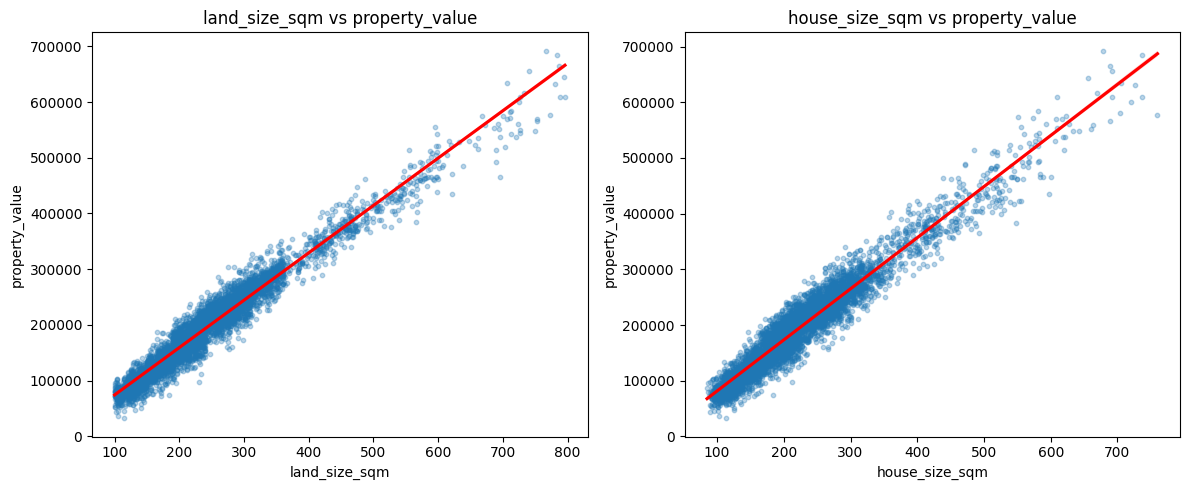

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(data=df, x='land_size_sqm', y='property_value', ax=axes[0],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[0].set_title('land_size_sqm vs property_value')

sns.regplot(data=df, x='house_size_sqm', y='property_value', ax=axes[1],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[1].set_title('house_size_sqm vs property_value')

plt.tight_layout()
plt.show()

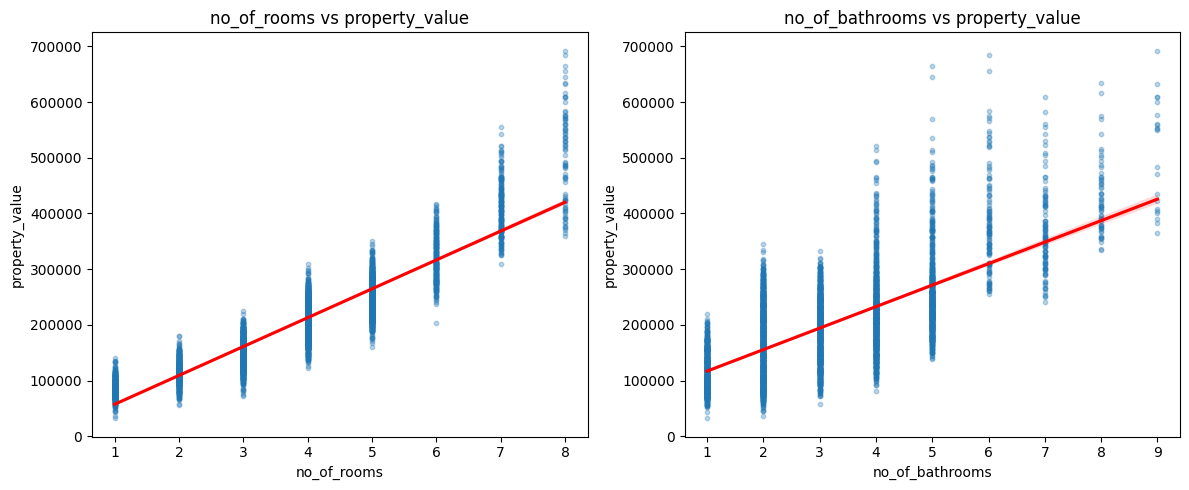

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(data=df, x='no_of_rooms', y='property_value', ax=axes[0],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[0].set_title('no_of_rooms vs property_value')

sns.regplot(data=df, x='no_of_bathrooms', y='property_value', ax=axes[1],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[1].set_title('no_of_bathrooms vs property_value')

plt.tight_layout()
plt.show()

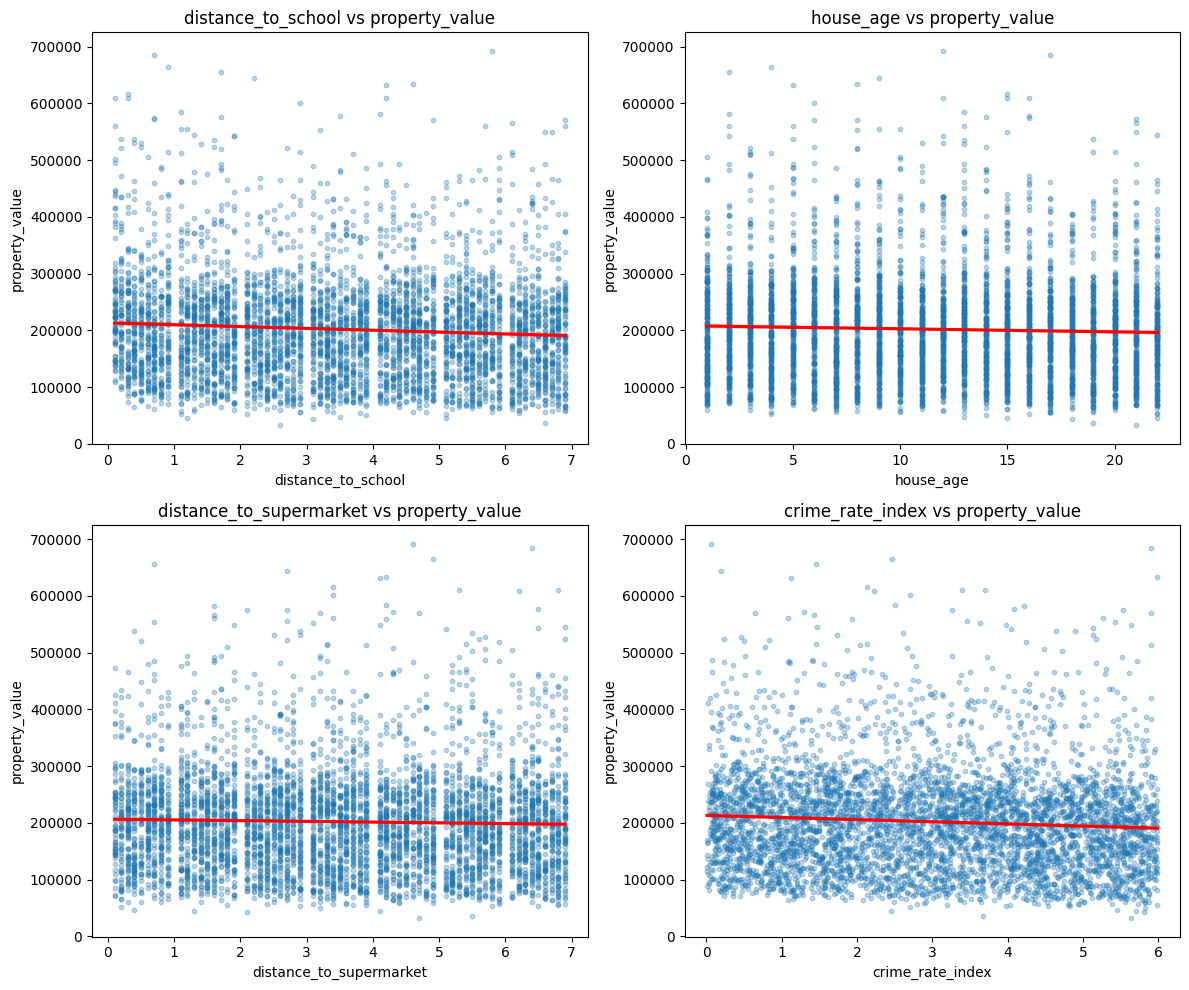

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

no_relationship_cols = ['distance_to_school', 'house_age', 'distance_to_supermarket', 'crime_rate_index']

for i, col in enumerate(no_relationship_cols):
    sns.regplot(data=df, x=col, y='property_value', ax=axes[i],
                scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs property_value')

plt.tight_layout()
plt.show()

### Step 3b: Overlapping data


Took help of AI to generate the box plots

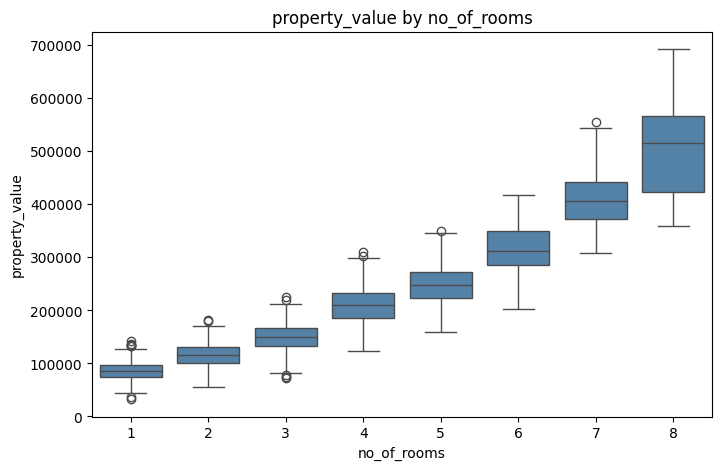

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='no_of_rooms', y='property_value', color='steelblue')
plt.title('property_value by no_of_rooms')
plt.show()

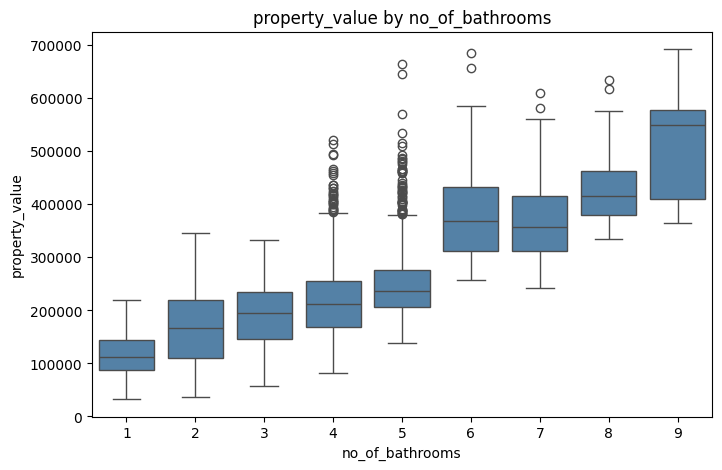

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='no_of_bathrooms', y='property_value', color='steelblue')
plt.title('property_value by no_of_bathrooms')
plt.show()

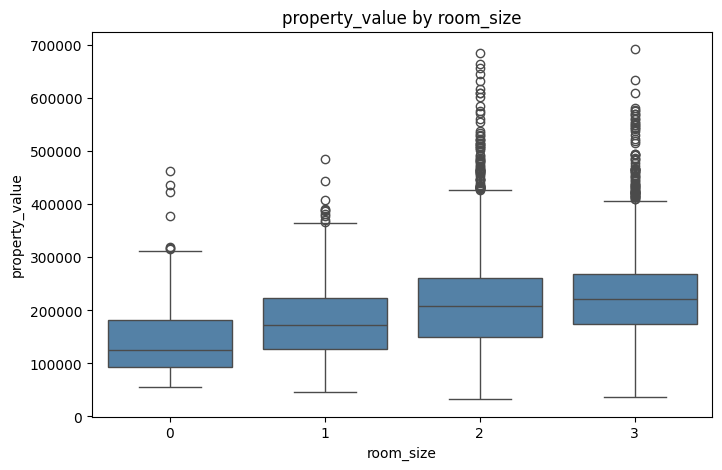

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='room_size', y='property_value',
            order=[0, 1, 2, 3], color='steelblue')
plt.title('property_value by room_size')
plt.show()

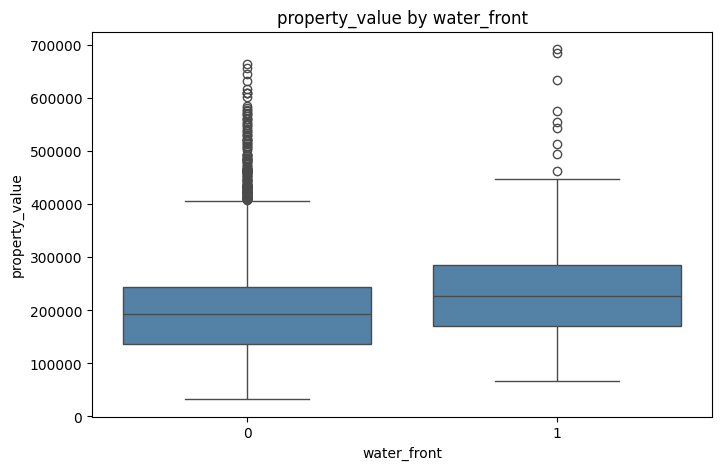

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='water_front', y='property_value', color='steelblue')
plt.title('property_value by water_front')
plt.show()

In [14]:
# Step 3c: Outlier detection using IQR method
numeric_cols = ['land_size_sqm', 'house_size_sqm', 'no_of_rooms', 'no_of_bathrooms',
                 'distance_to_school', 'house_age', 'distance_to_supermarket',
                 'crime_rate_index', 'property_value']

results = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    results.append({
        'column': col,
        'lower_bound': round(lower, 1),
        'upper_bound': round(upper, 1),
        'n_outliers': len(outliers),
        'pct_outliers': round(100 * len(outliers) / len(df), 2)
    })

res_df = pd.DataFrame(results).sort_values('n_outliers', ascending=False)
res_df

,column,lower_bound,upper_bound,n_outliers,pct_outliers
0,land_size_sqm,7.5,467.5,214,4.32
1,house_size_sqm,1.5,437.5,205,4.14
8,property_value,-27942.5,411309.5,163,3.29
3,no_of_bathrooms,-1.0,7.0,81,1.64
2,no_of_rooms,0.0,8.0,0,0.00
4,distance_to_school,-3.6,10.4,0,0.00
5,house_age,-10.5,33.5,0,0.00
6,distance_to_supermarket,-3.4,10.6,0,0.00
7,crime_rate_index,-3.1,9.0,0,0.00


In [15]:
def get_outlier_idx(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return set(df[(df[col] < lower) | (df[col] > upper)].index)

land_idx = get_outlier_idx('land_size_sqm')
house_idx = get_outlier_idx('house_size_sqm')
price_idx = get_outlier_idx('property_value')

print("land & house overlap:", len(land_idx & house_idx))
print("land & price overlap:", len(land_idx & price_idx))
print("house & price overlap:", len(house_idx & price_idx))
print("all three overlap:", len(land_idx & house_idx & price_idx))
print("union (flagged by at least one):", len(land_idx | house_idx | price_idx))

land & house overlap: 192
land & price overlap: 156
house & price overlap: 154
all three overlap: 153
union (flagged by at least one): 233


In [16]:
from sklearn.ensemble import IsolationForest

numeric_cols = ['land_size_sqm', 'house_size_sqm', 'no_of_rooms', 'no_of_bathrooms',
                 'distance_to_school', 'house_age', 'distance_to_supermarket',
                 'crime_rate_index', 'property_value']

X = df[numeric_cols]

iso = IsolationForest(contamination=0.05, random_state=42)
df['iso_outlier'] = iso.fit_predict(X)  # -1 = outlier, 1 = normal

n_outliers = (df['iso_outlier'] == -1).sum()
print(f"Isolation Forest outliers: {n_outliers} ({100*n_outliers/len(df):.2f}%)")

Isolation Forest outliers: 248 (5.01%)


In [17]:
# --- Step 1: Get the IQR outlier index sets (reuse the function from before) ---
def get_outlier_idx(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return set(df[(df[col] < lower) | (df[col] > upper)].index)

# union of the columns that actually had IQR outliers
iqr_union = (get_outlier_idx('land_size_sqm') 
             | get_outlier_idx('house_size_sqm') 
             | get_outlier_idx('property_value') 
             | get_outlier_idx('no_of_bathrooms'))

# --- Step 2: Get the Isolation Forest outlier index set ---
iso_idx = set(df[df['iso_outlier'] == -1].index)

# --- Step 3: Compare ---
print("IQR union (4 columns):", len(iqr_union))
print("Isolation Forest:", len(iso_idx))
print("Overlap (flagged by both):", len(iqr_union & iso_idx))
print("Only flagged by IQR:", len(iqr_union - iso_idx))
print("Only flagged by Isolation Forest:", len(iso_idx - iqr_union))

# --- Step 4: Inspect a sample of rows Isolation Forest caught that IQR missed ---
only_iso = df.loc[list(iso_idx - iqr_union)][numeric_cols]
print("\nSample of rows flagged ONLY by Isolation Forest (not by IQR):")
only_iso.head(8)

IQR union (4 columns): 251
Isolation Forest: 248
Overlap (flagged by both): 214
Only flagged by IQR: 37
Only flagged by Isolation Forest: 34

Sample of rows flagged ONLY by Isolation Forest (not by IQR):


,land_size_sqm,house_size_sqm,no_of_rooms,no_of_bathrooms,distance_to_school,house_age,distance_to_supermarket,crime_rate_index,property_value
2434,455,408,6,4,3.1,20,0.1,0.37,375863
4740,450,428,6,4,4.6,5,6.8,5.85,345279
651,411,388,7,5,4.6,22,1.7,0.16,346824
4883,111,96,1,2,1.4,20,0.6,0.26,86040
4890,101,101,1,1,1.1,22,0.2,2.70,51999
1691,395,338,6,7,0.5,4,6.7,5.96,330855
1179,464,428,8,6,1.7,21,5.7,1.75,392746
540,110,99,1,1,6.9,22,5.7,5.20,68727


##### Let's check the noise

In [ ]:
# Checking the noise in the dataset using R2 score and residual standard deviation
# I came to know about this from Claude, an AI assistant. I asked him to write a code snippet to check the noise in the dataset using R2 score and residual standard deviation. The code snippet is as follows:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

feature_cols = ['land_size_sqm', 'house_size_sqm', 'no_of_rooms', 'no_of_bathrooms',
                 'distance_to_school', 'house_age', 'distance_to_supermarket', 'crime_rate_index']

results = []
for col in feature_cols:
    X = df[[col]]
    y = df['property_value']
    model = LinearRegression().fit(X, y)
    preds = model.predict(X)
    r2 = r2_score(y, preds)
    residual_std = np.std(y - preds)
    results.append({'feature': col, 'R2_with_target': round(r2, 3), 'residual_std': round(residual_std, 0)})

res_df = pd.DataFrame(results).sort_values('R2_with_target', ascending=False)
res_df

,feature,R2_with_target,residual_std
0,land_size_sqm,0.948,20525.0
1,house_size_sqm,0.930,23884.0
2,no_of_rooms,0.832,36895.0
3,no_of_bathrooms,0.471,65456.0
4,distance_to_school,0.005,89787.0
7,crime_rate_index,0.005,89784.0
5,house_age,0.001,89958.0
6,distance_to_supermarket,0.001,89986.0


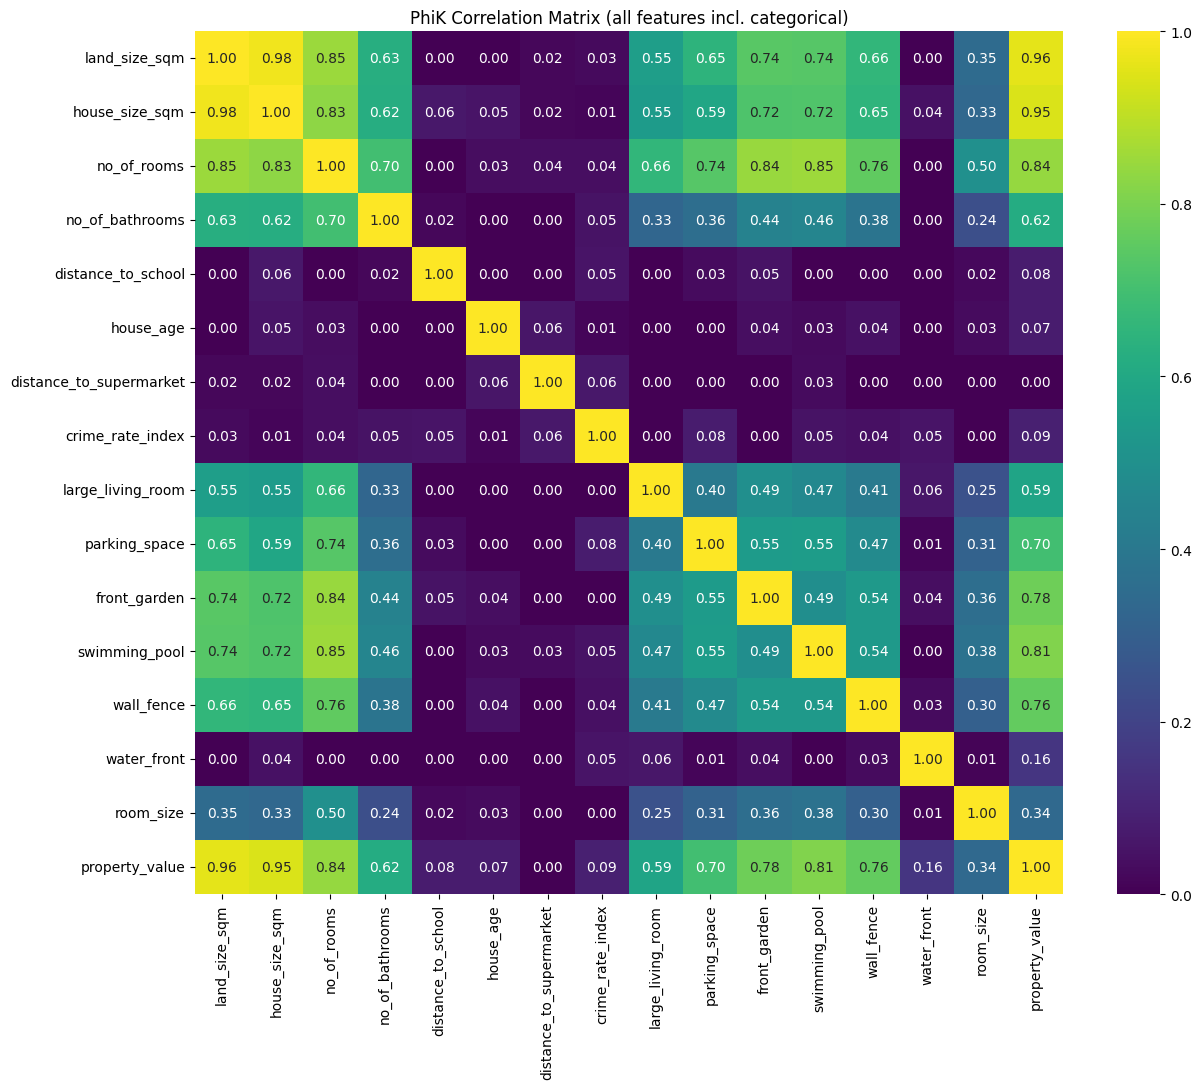

property_value             1.000000
land_size_sqm              0.959587
house_size_sqm             0.945082
no_of_rooms                0.841216
swimming_pool              0.811492
front_garden               0.777996
wall_fence                 0.758132
parking_space              0.699140
no_of_bathrooms            0.616451
large_living_room          0.585422
room_size                  0.337582
water_front                0.155097
crime_rate_index           0.086516
distance_to_school         0.077870
house_age                  0.074448
distance_to_supermarket    0.000000
Name: property_value, dtype: float64


In [19]:
import phik
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['land_size_sqm', 'house_size_sqm', 'no_of_rooms', 'no_of_bathrooms',
        'distance_to_school', 'house_age', 'distance_to_supermarket', 'crime_rate_index',
        'large_living_room', 'parking_space', 'front_garden', 'swimming_pool',
        'wall_fence', 'water_front', 'room_size', 'property_value']

# tell phik which columns are continuous (interval) vs categorical
interval_cols = ['land_size_sqm', 'house_size_sqm', 'no_of_rooms', 'no_of_bathrooms',
                  'distance_to_school', 'house_age', 'distance_to_supermarket',
                  'crime_rate_index', 'property_value']

phik_df = df[cols].phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(13, 11))
sns.heatmap(phik_df, annot=True, fmt='.2f', cmap='viridis')
plt.title('PhiK Correlation Matrix (all features incl. categorical)')
plt.tight_layout()
plt.show()

# specifically check correlation with target, sorted
print(phik_df['property_value'].sort_values(ascending=False))

### Step 3e: Feature importance

In [21]:
TARGET_VARIABLE = "property_value"

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE, mutual_info_regression, mutual_info_classif

# typical X/y -split
feature_cols = ['land_size_sqm', 'house_size_sqm', 'no_of_rooms', 'no_of_bathrooms',
                 'distance_to_school', 'house_age', 'distance_to_supermarket', 'crime_rate_index',
                 'large_living_room', 'parking_space', 'front_garden', 'swimming_pool',
                 'wall_fence', 'water_front', 'room_size']

X = df[feature_cols]
y = df[TARGET_VARIABLE]

# define model (linear regression, random forest, XGBoost etc.)
# technically you can use pretty much any classic ML algorithm
# model = LinearRegression()

# idea: you might want to try RFE with multuple ML algorithms
# and then cross-validate the results (which results are common in all models)

# another idea: if you plan on using e.g. XGBoost in your final model
# it's probably a good idea to use the same XGBoost here
model = RandomForestRegressor()

# create RFE, place the model and choose number of optimal variables
rfe = RFE(estimator=model, n_features_to_select=7)

# fit the RFE model with our data
rfe.fit(X, y)

# get rankings and results
rankings = rfe.ranking_
support = rfe.support_

# build a DataFrame to wrap up result for easier inspection
results_df = pd.DataFrame({
    "Feature": X.columns,
    "Ranking": rankings,
    "Selected": support
}).sort_values(by="Ranking")

# you can use these results with any other knowledge you have
# from other optimal variable selection tools, and cross-validation
results_df

,Feature,Ranking,Selected
0,land_size_sqm,1,True
1,house_size_sqm,1,True
2,no_of_rooms,1,True
4,distance_to_school,1,True
7,crime_rate_index,1,True
5,house_age,1,True
12,wall_fence,1,True
13,water_front,2,False
11,swimming_pool,3,False
6,distance_to_supermarket,4,False


In [23]:
from sklearn.feature_selection import SelectKBest, f_regression

feature_cols = ['land_size_sqm', 'house_size_sqm', 'no_of_rooms', 'no_of_bathrooms',
                 'distance_to_school', 'house_age', 'distance_to_supermarket', 'crime_rate_index',
                 'large_living_room', 'parking_space', 'front_garden', 'swimming_pool',
                 'wall_fence', 'water_front', 'room_size']

X = df[feature_cols]
y = df['property_value']

# f_regression is the correct scoring function for a CONTINUOUS target
# (chi2 is for classification/categorical targets, not used here)
skb = SelectKBest(score_func=f_regression, k='all')
skb.fit(X, y)

skb_results = pd.DataFrame({
    'feature': feature_cols,
    'f_score': skb.scores_,
    'p_value': skb.pvalues_
}).sort_values('f_score', ascending=False)

skb_results

,feature,f_score,p_value
0,land_size_sqm,90310.328305,0.000000e+00
1,house_size_sqm,65399.213856,0.000000e+00
2,no_of_rooms,24528.933503,0.000000e+00
3,no_of_bathrooms,4414.675832,0.000000e+00
11,swimming_pool,2379.164248,0.000000e+00
10,front_garden,2074.540358,0.000000e+00
12,wall_fence,1935.300406,0.000000e+00
9,parking_space,1328.049795,8.162562e-258
8,large_living_room,970.719536,9.146169e-195
14,room_size,556.488471,1.076616e-116


In [25]:
# Step 3f/4f: Check consistency of price per square meter
df['price_per_sqm'] = df['property_value'] / df['house_size_sqm']

print(df['price_per_sqm'].describe())

count    4954.000000
mean      862.822705
std       118.061418
min       288.690265
25%       791.951118
50%       865.315558
75%       941.403083
max      1279.959184
Name: price_per_sqm, dtype: float64


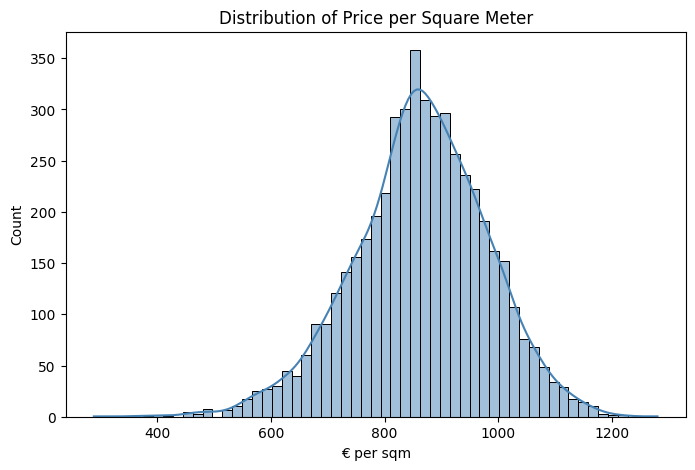

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price_per_sqm'], kde=True, color='steelblue')
plt.title('Distribution of Price per Square Meter')
plt.xlabel('€ per sqm')
plt.show()